In [25]:
# %matplotlib widget
import sys
sys.path.append('..')

import os
import sys
import numpy as np
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
from mpl_toolkits import mplot3d
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
import math
from IPython.display import HTML
from tqdm import tqdm
import random
from numpy.lib import recfunctions as rfn

from sklearn.cluster import DBSCAN
from scipy.interpolate import interp1d
from scipy.spatial import KDTree
from scipy.interpolate import interpn
# import cupy as cp
import time
import numba as nb

# 画图部分
import matplotlib as mpl
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import ImageGrid
from functools import partial
import matplotlib.cm as cm

# ROC曲线部分
from sklearn.metrics import roc_curve, auc
from sklearn import metrics

# 插值
import torch
# import torch.cuda as cuda
from scipy.interpolate import griddata

# 系数拟合部分
from scipy.optimize import curve_fit
from sklearn import svm

In [61]:
from importlib import reload  
  
reload(matplotlib)

<module 'matplotlib' from '/home/cchang/.conda/envs/geant4/lib/python3.8/site-packages/matplotlib/__init__.py'>

In [26]:
# 概率比较部分
from scipy.special import gammaln
# import torch.distributions as dist

# 位置重建函数
import position_rec as pos

import DE
from DE import DESimulation
import importlib

import os
import glob
import re

CEVNS数据
=====

In [3]:
# data_now = np.load("cevns_sim_100.npz")
# 倒入能谱数据
data = np.load("../cevns_sim.npz")
data_original = np.load("e_spectrum_relics.npz")

In [4]:
# data = np.load("../cevns_sim.npz")


# 创建一个字典来复制数据
new_data_dict = {key: data[key] for key in data.files}

# 修改特定的数据, 按照20倍曝光量模拟3电子及以上事件
new_data_dict['CEvNS'] = data_original['CEvNS']* 32 * 20

new_data_dict['CEvNS'][:3] = 1

print(new_data_dict['CEvNS'])

np.savez('cevns_sim_20_3e.npz',**new_data_dict)

[1.00000000e+00 1.00000000e+00 1.00000000e+00 4.54032441e+05
 1.95825427e+05 8.88137882e+04 4.06376411e+04 1.83901864e+04
 8.14474283e+03 3.50835773e+03 1.46412625e+03 5.90532988e+02
 2.29861964e+02 8.62790248e+01 3.12189475e+01 1.08894762e+01
 3.66245376e+00 1.18819120e+00 3.72026798e-01 1.12485900e-01]


In [5]:
cevns_v2= np.array([0.37417449009388115,
 0.3109397312767753,
 0.16717200606407276,
 0.07893294719536634,
 0.03659243910926931,
 0.017214206570478847,
 0.008146097753173038,
 0.0038070456845482148,
 0.0016640199682396188,
 0.0007810093721124653,
 0.0003360040320483846,
 0.00015200182402188826,
 6.600079200950411e-05,
 2.2000264003168037e-05])
np.save("cevns_v2", cevns_v2)

In [6]:
file_load_once = 100
param = 0

test_DE_sim = DESimulation('DE_param_30_test.yaml')

muon_file_list = []
for i in range(file_load_once):
    # print(i)
    file_index = param * file_load_once + i
    filename = test_DE_sim.load_folder_path + \
        "muon_track/muon_track." + str(file_index) + ('.npy')
    # print(filename)
    muon_file_list.append(filename)

In [7]:
test_DE_sim.generate_muon_points(muon_file_list)
print(test_DE_sim.time_range/3600)
print(test_DE_sim.cevns_e_spectrum)

 36%|██████████████████████████████████████████████████████████████████████████▉                                                                                                                                     | 36/100 [00:00<00:00, 357.24it/s]

/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.0.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.1.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.2.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.3.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.4.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.5.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.6.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.7.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.8.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.9.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.10.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.11.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.12.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.13.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 359.44it/s]


/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.72.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.73.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.74.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.75.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.76.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.77.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.78.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.79.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.80.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.81.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.82.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.83.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.84.npy
/home/cchang/RELICS_DE_sim/file_to_load/muon_track/muon_track.85.npy
/home/cchang/RELICS_DE_sim/file_to

In [8]:
print(test_DE_sim.time_range/3600)

8.51859078590786


In [9]:
test_DE_sim.generate_CEVNS_points()
test_DE_sim.generate_CEVNS_pattern()
test_DE_sim.CEVNS_position_recon()
test_DE_sim.generate_CEVNS_recon_pattern()
test_DE_sim.CEVNS_sp_cor()

Interpn for channel:  0
Interpn for channel:  1
Interpn for channel:  2
Interpn for channel:  3
Interpn for channel:  4
Interpn for channel:  5
Interpn for channel:  6
Interpn for channel:  7
Interpn for channel:  8
Interpn for channel:  9
Interpn for channel:  10
Interpn for channel:  11
Interpn for channel:  12
Interpn for channel:  13
Interpn for channel:  14
Interpn for channel:  15
Interpn for channel:  16
Interpn for channel:  17
Interpn for channel:  18
Interpn for channel:  19
Interpn for channel:  20
Interpn for channel:  21
Interpn for channel:  22
Interpn for channel:  23
Interpn for channel:  24
Interpn for channel:  25
Interpn for channel:  26
Interpn for channel:  27
Interpn for channel:  28
Interpn for channel:  29
Interpn for channel:  30
Interpn for channel:  31
Interpn for channel:  32
Interpn for channel:  33
Interpn for channel:  34
Interpn for channel:  35
Interpn for channel:  36
Interpn for channel:  37
Interpn for channel:  38
Interpn for channel:  39
Interpn fo

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 31572/31572 [00:00<00:00, 121868.85it/s]


Start pos recon for event size:  2
(1, 64)
GPU is busy, waiting.
1
done of generating test files
Start pos recon for event size:  3
(454032, 64)
454032
10000 / 454032 ,time: 0.12255406379699707
20000 / 454032 ,time: 0.13840460777282715
30000 / 454032 ,time: 0.1183176040649414
40000 / 454032 ,time: 0.1193845272064209
50000 / 454032 ,time: 0.11843514442443848
60000 / 454032 ,time: 0.11786985397338867
70000 / 454032 ,time: 0.11673688888549805
80000 / 454032 ,time: 0.1177361011505127
90000 / 454032 ,time: 0.11770248413085938
100000 / 454032 ,time: 0.11792683601379395
110000 / 454032 ,time: 0.12090611457824707
120000 / 454032 ,time: 0.11760997772216797
130000 / 454032 ,time: 0.11652684211730957
140000 / 454032 ,time: 0.11815452575683594
150000 / 454032 ,time: 0.11742925643920898
160000 / 454032 ,time: 0.11844015121459961
170000 / 454032 ,time: 0.11795663833618164
180000 / 454032 ,time: 0.11828947067260742
190000 / 454032 ,time: 0.11760187149047852
200000 / 454032 ,time: 0.11850357055664062


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 6159.04it/s]


平均电子数：  1.3410683377556107
last_muon_id.shape:  (454032,)
last_muon_id[-10:]:  [314326 314328 314328 314328 314329 314330 314330 314330 314332 314332]
0
0 100000


...

平均电子数：  7.243476800746549
last_muon_id.shape:  (8144,)
last_muon_id[-10:]:  [313959 314022 314084 314116 314126 314231 314234 314237 314299 314323]
0
0 8144


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8144/8144 [00:00<00:00, 12384.82it/s]


平均电子数：  8.287933707207547
last_muon_id.shape:  (3508,)
last_muon_id[-10:]:  [313761 313779 313850 313875 313922 314026 314042 314047 314119 314149]
0
0 3508


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3508/3508 [00:00<00:00, 7839.05it/s]


平均电子数：  9.326858720414775


In [10]:
cevns_points = np.concatenate((test_DE_sim.cevns_points))
del test_DE_sim

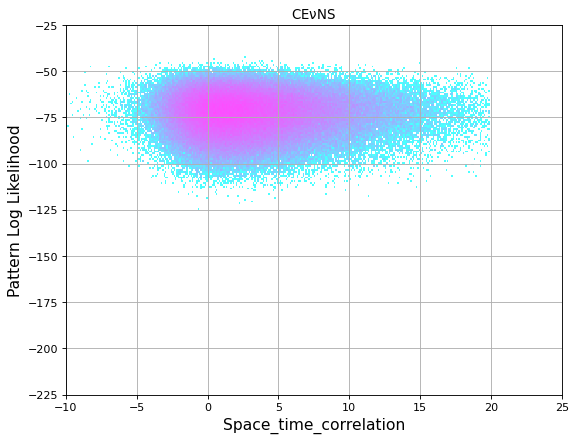

In [62]:
def calculate_poisson_probabilities_log(data_array, mean_array):
    # 计算每个元素的对数概率
    log_probabilities = -mean_array + data_array * np.log(mean_array) - gammaln(data_array + 1)
    return log_probabilities

# 定义cevns点的三参数
cevns_info = np.zeros(len(cevns_points),dtype = np.dtype([('area', '<f8'),('st_cor', '<f8'),('pattern', '<f8'),('e_num','uint32')]))
cevns_info['area'] = np.sum(cevns_points['pe_by_area'],axis = 1)
cevns_info['st_cor'] = np.log(cevns_points['st_cor'])
# cevns_info['st_cor_new'] = np.log(cevns_points['st_cor_new'])
cevns_info['pattern'] = np.sum(calculate_poisson_probabilities_log(
         cevns_points['pe_by_area'][:,:64], cevns_points['recons_light_pattern'][:,:64]),axis = 1)
cevns_info['e_num'] = cevns_points['num_e']

# 选定面积在120PE到300pe的时间
mask = (cevns_info['area'] > 90) * (cevns_info['area'] < 300)
mask_roi = (cevns_info['area'] > 120) * (cevns_info['area'] < 300)
cevns_info_area = cevns_info[mask]
cevns_info_roi = cevns_info[mask_roi]


x_bins = np.arange(-10,20,0.1)
y_bins = np.arange(-250,-0,1)
# 绘制二维直方图
fig = plt.figure(figsize=(8, 6), dpi=80)  # 调整 figsize 参数以设置合适的宽度和高度
#plt.hist2d(real_space_time_cor_veto, real_log_l_veto_4, bins=500 , cmap='hot', norm=LogNorm(),alpha = 0.7,label='Real Event')
#plt.colorbar(pad = -0.01)
H = plt.hist2d(cevns_info_roi['st_cor'], cevns_info_roi['pattern'], bins = [x_bins, y_bins], cmap='cool', norm=LogNorm(),alpha = 0.7,label = 'DE Event')
#mask = test_DE_sim.CEVNS_sp_cor[0] > 0
# H = plt.hist2d(np.log(test_DE_sim.CEVNS_sp_cor[0][mask]), CEVNS_pattern_possion[0][mask],  bins = 500, cmap='hot', norm=LogNorm(),alpha = 0.7,label = 'CEVNS Event')
plt.xlabel('Space_time_correlation',fontsize = 14)
plt.ylabel('Pattern Log Likelihood',fontsize = 14)
plt.title(r'$\mathrm{CE\nu NS}$')
plt.xlim(-10, 25)
plt.ylim(-225,-25)
plt.grid()
# plt.savefig("Cevns_dis.png")
plt.show()



导入所有需要的数，分析score参数
=====

In [198]:
def list_files(path,N = 18459):
    files = glob.glob(os.path.join(path, '*.npz'))  # 获取所有匹配的文件路径名
    print(len(files))
    files = sorted(files, key=lambda x: int(re.match(r'(\d+)', os.path.basename(x)).group(1)))  # 提取文件名中的数值部分并以其为键进行排序
    # for file in files[:N]:
    #     print(file)
    return files
        
# 将路径替换为需要使用的路径
file_list = list_files("DE_result_0822")

18459


In [199]:
len(file_list),file_list[-1]

(18459, 'DE_result_0822/99995.npz')

In [156]:
pile_up_pattern_coefficient_list = []
pile_up_area_list = []
pile_up_e_num_list = []
pile_up_sp_cor_list = []

for i in tqdm(range(1000)):
    file = np.load(file_list[i])
    pile_up_pattern_coefficient = file['pile_up_pattern_coefficient']
    pile_up_area =  file["pile_up_area"]
    # area_pattern =  data_save["area_pattern"]
    # pile_up_pe_info = data_save["pile_up_pe_info"]
    pile_up_e_num =  file["pile_up_e_num"]
    pile_up_sp_cor = file['pile_up_sp_cor']
    
    pile_up_pattern_coefficient_list.append(pile_up_pattern_coefficient)
    pile_up_area_list.append(pile_up_area)
    pile_up_e_num_list.append(pile_up_e_num)
    pile_up_sp_cor_list.append(pile_up_sp_cor)
    
    del file
    
pile_up_pattern_coefficient = np.concatenate(pile_up_pattern_coefficient_list)
pile_up_area = np.concatenate(pile_up_area_list)
pile_up_e_num = np.concatenate(pile_up_e_num_list)
pile_up_sp_cor = np.concatenate(pile_up_sp_cor_list)

100%|██████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:12<00:00, 13.81it/s]


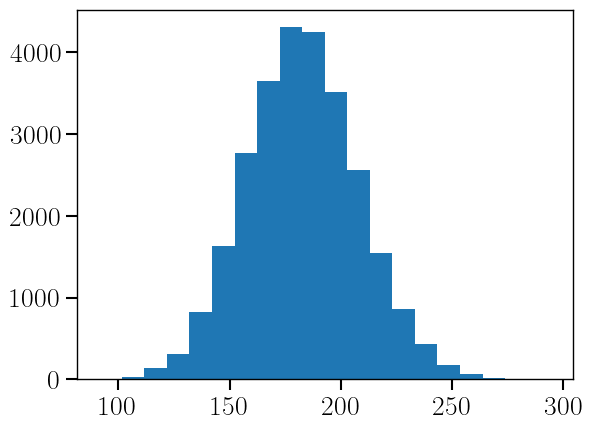

In [157]:
plt.hist(pile_up_area[pile_up_e_num == 6],bins = 20)
# plt.hist(pile_up_area[pile_up_e_num == 5])
plt.show()

In [158]:
len(pile_up_area[pile_up_e_num == 6]),len(pile_up_area[pile_up_e_num == 5]),len(pile_up_area[pile_up_e_num == 4])

(27109, 302843, 3650099)

In [159]:
roi_mask_DE = (pile_up_area > 120) * (pile_up_area < 300)
area_mask_DE = (pile_up_area > 90) * (pile_up_area < 3-0)

pile_up_pattern_coefficient_roi = pile_up_pattern_coefficient[roi_mask_DE]
pile_up_area_roi = pile_up_area[roi_mask_DE]
pile_up_e_num_roi = pile_up_e_num[roi_mask_DE]
pile_up_sp_cor_roi = pile_up_sp_cor[roi_mask_DE]

pile_up_pattern_coefficient_area = pile_up_pattern_coefficient[area_mask_DE]
pile_up_area_area = pile_up_area[area_mask_DE]
pile_up_e_num_area = pile_up_e_num[area_mask_DE]
pile_up_sp_cor_area = pile_up_sp_cor[area_mask_DE]

In [160]:
# del pile_up_pattern_coefficient_list
# del pile_up_area_list
# del pile_up_e_num_list
# del pile_up_sp_cor_list

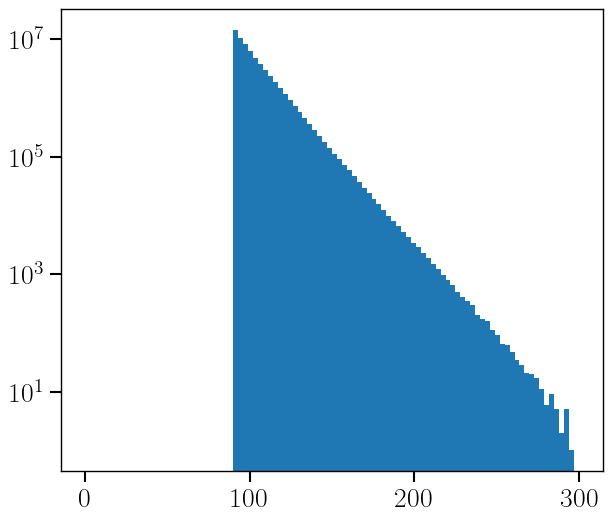

In [161]:
# pile-up信号面积分布
fig = plt.figure(figsize=(7,6))
# plt.style.use('../relics.mplstyle')  
plt.hist(pile_up_area,bins = np.linspace(0,300,101),log=True)
plt.yscale('log')
# plt.xlabel(r'$\mathrm{S2\ Area[PE]}$')
# plt.tight_layout()
# plt.savefig("Muon_power.png")
plt.show()

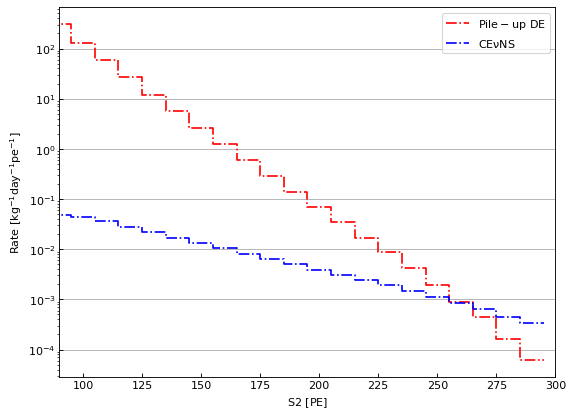

In [162]:
import importlib 
importlib.reload(matplotlib)

DE_spectrum_original,bins_edge = np.histogram(pile_up_area, bins=np.arange(90,301,10))
cevns_spectrum_original,bins_edge = np.histogram(cevns_info_area['area'], bins=np.arange(90,301,10))

DE_rate_original = DE_spectrum_original / 8500 * 24 / 32 / 10 #1000个文件，850h
cevns_rate_original = cevns_spectrum_original / 20 / 365 / 10 / 32

# 在最左侧插入数据点
pe = (bins_edge[1:] + bins_edge[:-1])/2
rate_DE = DE_rate_original
rate_CEvNS = cevns_rate_original
pe = np.insert(pe, 0, pe[0] - 10)
rate_DE = np.insert(rate_DE, 0, rate_DE[0])
rate_CEvNS = np.insert(rate_CEvNS, 0, rate_CEvNS[0])

import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6), dpi=80)
# 创建一个柱状图并添加误差条
# ax.bar((bins_edge[1:] + bins_edge[:-1])/2, DE_rate_original, edgecolor = "black", label=r"DE",width=10,)
# ax.bar((bins_edge[1:] + bins_edge[:-1])/2, cevns_rate_original, edgecolor = "black", label=r"CE$\nu$NS",width=10,)
ax.plot(pe,rate_DE , '-.', c='r', label=r'$\mathrm{Pile-up\ DE}$',drawstyle='steps') 
ax.plot(pe,rate_CEvNS , '-.', c='b', label=r'$\mathrm{CE\nu NS}$', drawstyle='steps') 
# ax.errorbar((bins_edge[1:] + bins_edge[:-1])/2, DE_rate, yerr=DE_rate_error, color = "black")

ax.set_xlabel(r"$\mathrm{S2\ [PE]}$")
ax.set_ylabel(r"$\mathrm{Rate\ [kg^{-1} day^{-1} pe^{-1}]}$")
ax.set_yscale("log")
ax.set_xlim(90, 300)

# 设置y轴的刻度为每个10的n次方
# ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0))
ax.tick_params(direction='in')
# 增加背景刻度线
ax.grid(which='major', axis='y')

plt.legend()
# plt.savefig("DE_original_rate.pdf")
plt.show()

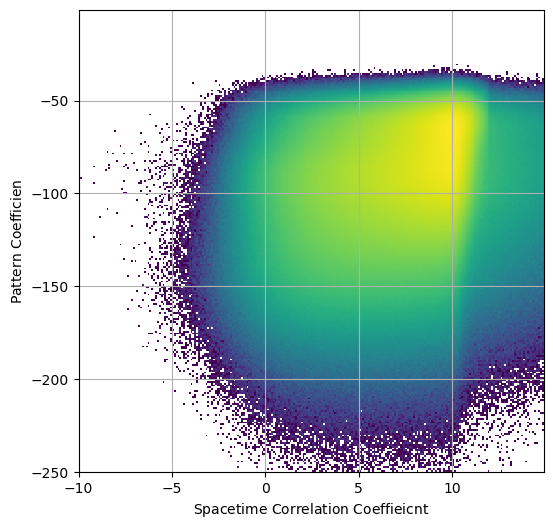

In [163]:
x_bins = np.arange(-10,15,0.1)
y_bins = np.arange(-250,-0,1)

# roi_mask_cevns = (cevns_info['area'] > 120) * (cevns_info['area'] < 240)


plt.figure(figsize=(6,6))  # 调整 figsize 参数以设置合适的宽度和高度
#plt.hist2d(real_space_time_cor_veto, real_log_l_veto_4, bins=500 , cmap='hot', norm=LogNorm(),alpha = 0.7,label='Real Event')
#plt.colorbar(pad = -0.01)

# H = plt.hist2d(cevns_info['st_cor'], cevns_info['pattern'],  bins = [x_bins, y_bins], norm=LogNorm(),alpha = 0.5,label = 'CEvNS Event', cmap='cool')
H = plt.hist2d(pile_up_sp_cor, pile_up_pattern_coefficient,  bins = [x_bins, y_bins], norm=LogNorm(),alpha = 1,label = 'CEvNS Event')
#mask = test_DE_sim.CEVNS_sp_cor[0] > 0
# H = plt.hist2d(np.log(test_DE_sim.CEVNS_sp_cor[0][mask]), CEVNS_pattern_possion[0][mask],  bins = 500, cmap='hot', norm=LogNorm(),alpha = 0.7,label = 'CEVNS Event')
plt.xlabel(r'$\mathrm{Spacetime\  Correlation\ Coeffieicnt}$')
plt.ylabel(r'$\mathrm{Pattern\ Coefficien}$')
# plt.title('3e')
plt.grid()
# plt.savefig("Pattern_dis.png")
plt.show()

In [164]:
len(pile_up_sp_cor_roi)

5608664

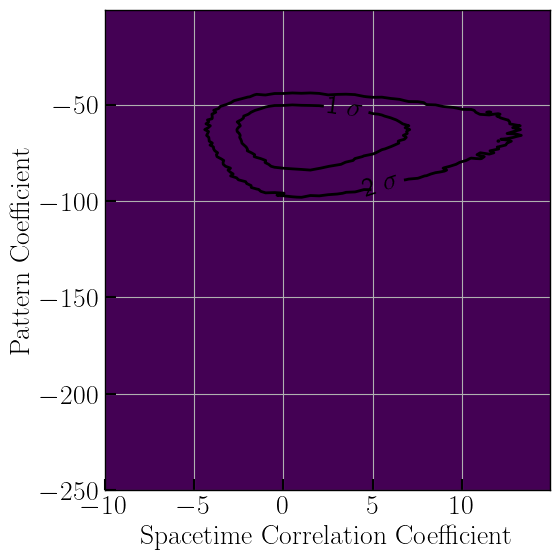

In [165]:
x_bins_new = np.arange(-10,15,0.5)
y_bins_new = np.arange(-250,-0,5)

x_bins = np.arange(-10,15,0.1)
y_bins = np.arange(-250,-0,1)

hist_new, xedges_new, yedges_new = np.histogram2d(cevns_info_area['st_cor'], cevns_info_area['pattern'], bins=[x_bins_new, y_bins])
x_mesh_new, y_mesh_new = np.meshgrid(xedges_new[:-1], yedges_new[:-1])

# cut_array = np.arange(0,1,0.2)
cut_array = [0.683,0.954]
value_array_new = np.arange(np.min(hist_new),np.max(hist_new),1)[::-1]
cut_value_new = []
cut_index = 0
for i in value_array_new:
    # print(i,"*****")
    bigger = np.sum(hist_new[hist_new>i])
    # print(bigger)
    if (bigger > np.sum(hist_new) * cut_array[cut_index]):
        # print("!!!!!!")
        # print(i,"*****")
        # print(bigger)
        # print(cut_array[cut_index])
        cut_value_new.append(i)
        cut_index += 1
        if cut_index == len(cut_array):
            break
    

# plt.figure(figsize=(6,6))
# plt.style.use('../relics.mplstyle')
# plt.tick_params(direction='in')
# # 使用contour生成等高线图
# contour = plt.contour(x_mesh_new, y_mesh_new,hist_new.T,cut_value_new[::-1],colors = 'k')
# H = plt.hist2d(cevns_info_area['st_cor'], cevns_info_area['pattern'],  bins = [x_bins, y_bins], norm=LogNorm(),alpha = 0.5,label = 'CEvNS Event', cmap='cool')
# H = plt.hist2d(pile_up_sp_cor_area, pile_up_pattern_coefficient_area,  bins = [x_bins, y_bins], norm=LogNorm(),alpha = 1,label = 'CEvNS Event')
# # 定义标签内容
# # labels = [(str(int(i*100))+" \%") for i in cut_array[1:][::-1]]
# labels = [r" 2 $\sigma$ ",r" 1 $\sigma$ "]
# # 添加标签
# plt.clabel(contour, inline=1, fontsize=20, fmt=dict(zip(contour.levels, labels)))
# plt.xlabel(r'$\mathrm{Spacetime\  Correlation\ Coeffieicnt}$')
# plt.ylabel(r'$\mathrm{Pattern\ Coefficien}$')
# plt.grid()
# plt.tight_layout() 
# # plt.savefig("pattern_coefficient_dis_select_range_150_160.pdf")
# plt.show()

select_mask_cevns = (cevns_info_area['area'] > 150) * (cevns_info_area['area'] < 160)
select_mask_DE = (pile_up_area_area > 150) * (pile_up_area_area < 160)
plt.figure(figsize=(6,6))
plt.style.use('../relics.mplstyle')
plt.tick_params(direction='in')
# 使用contour生成等高线图
contour = plt.contour(x_mesh_new, y_mesh_new,hist_new.T,cut_value_new[::-1],colors = 'k')
H = plt.hist2d(cevns_info_area[select_mask_cevns]['st_cor'], cevns_info_area[select_mask_cevns]['pattern'],  bins = [x_bins, y_bins], norm=LogNorm(),alpha = 0.5,label = 'CEvNS Event', cmap='cool')
H = plt.hist2d(pile_up_sp_cor_area[select_mask_DE], pile_up_pattern_coefficient_area[select_mask_DE],  bins = [x_bins, y_bins], norm=LogNorm(),alpha = 1,label = 'CEvNS Event')
# 定义标签内容
# labels = [(str(int(i*100))+" \%") for i in cut_array[1:][::-1]]
labels = [r" 2 $\sigma$ ",r" 1 $\sigma$ "]
# 添加标签
plt.clabel(contour, inline=1, fontsize=20, fmt=dict(zip(contour.levels, labels)))
plt.xlabel(r'$\mathrm{Spacetime\  Correlation\ Coefficient}$')
plt.ylabel(r'$\mathrm{Pattern\ Coefficient}$')
plt.grid()
plt.tight_layout() 
# plt.savefig("pattern_coefficient_dis_select_range_150_160.pdf")
plt.show()

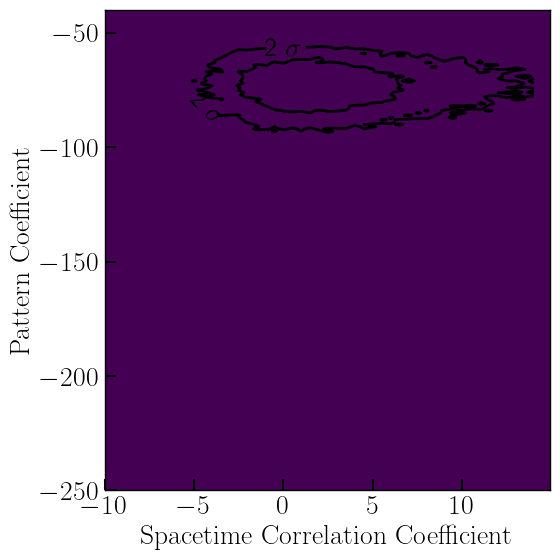

In [166]:
x_bins_new = np.arange(-10,15,0.5)
y_bins_new = np.arange(-250,-0,5)

# x_bins = np.arange(-10,15,0.2)
# y_bins = np.arange(-250,-0,2)    

# hist_new, xedges_new, yedges_new = np.histogram2d(cevns_info_roi['st_cor'], cevns_info_roi['pattern'], bins=[x_bins_new, y_bins])
# x_mesh_new, y_mesh_new = np.meshgrid(xedges_new[:-1], yedges_new[:-1])


# # cut_array = np.arange(0,1,0.2)
# cut_array = [0.683,0.954]
# value_array_new = np.arange(np.min(hist_new),np.max(hist_new),1)[::-1]
# cut_value_new = []
# cut_index = 0
# for i in value_array_new:
#     # print(i,"*****")
#     bigger = np.sum(hist_new[hist_new>i])
#     # print(bigger)
#     if (bigger > np.sum(hist_new) * cut_array[cut_index]):
#         # print("!!!!!!")
#         # print(i,"*****")
#         # print(bigger)
#         # print(cut_array[cut_index])
#         cut_value_new.append(i)
#         cut_index += 1
#         if cut_index == len(cut_array):
#             break

# plt.figure(figsize=(9,9))
# plt.style.use('../relics.mplstyle')
# plt.tick_params(direction='in')
# # 使用contour生成等高线图
# contour = plt.contour(x_mesh_new, y_mesh_new,hist_new.T,cut_value_new[::-1],colors = 'k')
# H = plt.hist2d(cevns_info_area['st_cor'], cevns_info_area['pattern'],  bins = [x_bins, y_bins], norm=LogNorm(),alpha = 0.5,label = 'CEvNS Event', cmap='cool')
# H = plt.hist2d(pile_up_sp_cor_area, pile_up_pattern_coefficient_area,  bins = [x_bins, y_bins], norm=LogNorm(),alpha = 1,label = 'CEvNS Event')
# # 定义标签内容
# # labels = [(str(int(i*100))+" \%") for i in cut_array[1:][::-1]]
# labels = [r" 2 $\sigma$ ",r" 1 $\sigma$ "]
# # 添加标签
# plt.clabel(contour, inline=1, fontsize=20, fmt=dict(zip(contour.levels, labels)))
# plt.xlabel(r'$\mathrm{Spacetime\  Correlation\ Coeffieicnt}$')
# plt.ylabel(r'$\mathrm{Pattern\ Coefficien}$')
# # plt.grid()
# plt.tight_layout() 
# # plt.savefig("pattern_coefficient_dis_select_range_150_160.pdf")
# plt.show()

select_mask_cevns = (cevns_info_area['area'] > 150) * (cevns_info_area['area'] < 160)
select_mask_DE = (pile_up_area_area > 150) * (pile_up_area_area < 160)

hist_new, xedges_new, yedges_new = np.histogram2d(cevns_info_area[select_mask_cevns]['st_cor'], cevns_info_area[select_mask_cevns]['pattern'], bins=[x_bins_new, y_bins])
x_mesh_new, y_mesh_new = np.meshgrid(xedges_new[:-1], yedges_new[:-1])

# cut_array = np.arange(0,1,0.2)
cut_array = [0.683,0.954]
value_array_new = np.arange(np.min(hist_new),np.max(hist_new),1)[::-1]
cut_value_new = []
cut_index = 0
for i in value_array_new:
    # print(i,"*****")
    bigger = np.sum(hist_new[hist_new>i])
    # print(bigger)
    if (bigger > np.sum(hist_new) * cut_array[cut_index]):
        # print("!!!!!!")
        # print(i,"*****")
        # print(bigger)
        # print(cut_array[cut_index])
        cut_value_new.append(i)
        cut_index += 1
        if cut_index == len(cut_array):
            break

plt.figure(figsize=(6,6))
plt.style.use('../relics.mplstyle')
plt.tick_params(direction='in')
# 使用contour生成等高线图
contour = plt.contour(x_mesh_new, y_mesh_new,hist_new.T,cut_value_new[::-1],colors = 'black')
H = plt.hist2d(cevns_info_area[select_mask_cevns]['st_cor'], cevns_info_area[select_mask_cevns]['pattern'],  bins = [x_bins, y_bins], norm=LogNorm(),alpha = 0.5,label = 'CEvNS Event', cmap='cool')
H = plt.hist2d(pile_up_sp_cor_area[select_mask_DE], pile_up_pattern_coefficient_area[select_mask_DE],  bins = [x_bins, y_bins], norm=LogNorm(),alpha = 1,label = 'CEvNS Event')
# 定义标签内容
# # labels = [(str(int(i*100))+" \%") for i in cut_array[1:][::-1]]
# labels = [r" 2 $\sigma$ ",r" 1 $\sigma$ "]
# # 添加标签
# plt.clabel(contour, inline=1, fontsize=20, fmt=dict(zip(contour.levels, labels)))

# 假设你有一个contour对象叫做contour
labels = [r" 2 $\sigma$ ",r" 1 $\sigma$ "]
positions = [(0, -60), (-5, -100)]  # 这只是一个假设的位置列表，实际使用时应调整为你需要的位置
plt.clabel(contour, inline=1, fontsize=20, fmt=dict(zip(contour.levels, labels)), manual=positions)


plt.xlabel(r'$\mathrm{Spacetime\  Correlation\ Coefficient}$')
plt.ylabel(r'$\mathrm{Pattern\ Coefficient}$')
plt.ylim(-250,-40)
#plt.grid()
plt.tight_layout() 
plt.savefig("pattern_coefficient_dis_select_range_150_160_2e4.pdf")
plt.show()

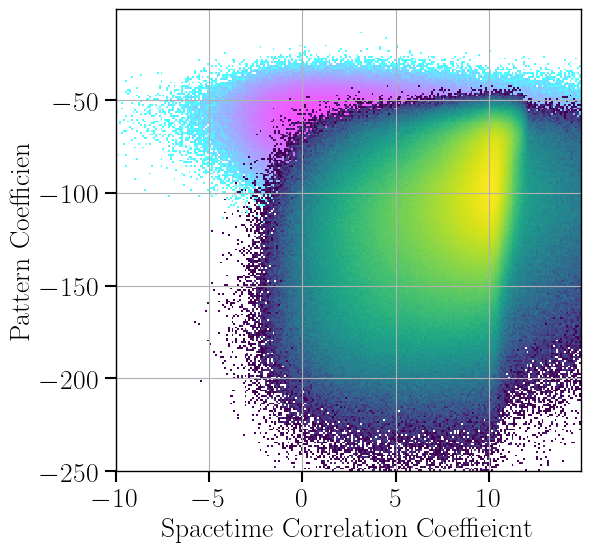

In [167]:
# 绘制二维直方图
x_bins = np.arange(-10,15,0.1)
y_bins = np.arange(-250,-0,1)

roi_mask_cevns = (cevns_info['area'] > 120) * (cevns_info['area'] < 240)
roi_mask_DE = (pile_up_area > 120) * (pile_up_area < 240)

plt.figure(figsize=(6,6))  # 调整 figsize 参数以设置合适的宽度和高度
#plt.hist2d(real_space_time_cor_veto, real_log_l_veto_4, bins=500 , cmap='hot', norm=LogNorm(),alpha = 0.7,label='Real Event')
#plt.colorbar(pad = -0.01)
H = plt.hist2d(cevns_info['st_cor'], cevns_info['pattern'], bins = [x_bins, y_bins] ,cmap='cool', norm=LogNorm(),alpha = 0.7,label = 'DE Event')
H = plt.hist2d(pile_up_sp_cor_roi, pile_up_pattern_coefficient_roi,  bins = [x_bins, y_bins], norm=LogNorm(),alpha = 1,label = 'CEvNS Event')
#mask = test_DE_sim.CEVNS_sp_cor[0] > 0
# H = plt.hist2d(np.log(test_DE_sim.CEVNS_sp_cor[0][mask]), CEVNS_pattern_possion[0][mask],  bins = 500, cmap='hot', norm=LogNorm(),alpha = 0.7,label = 'CEVNS Event')
plt.xlabel(r'$\mathrm{Spacetime\  Correlation\ Coeffieicnt}$')
plt.ylabel(r'$\mathrm{Pattern\ Coefficien}$')
# plt.title('3e')
plt.grid()
# plt.savefig("Pattern_dis_roi.png")
plt.show()

Pattern划分
=====

In [168]:
exposure = []
k_st_list = np.arange(2,10,0.2)
k_area_list = np.arange(0,2,0.1)
k_list = []
score_cevns = 0

for k_st in tqdm(k_st_list):
    exposure_k = []
    for k_area in k_area_list:
        # print(k_area)
        score_cevns = cevns_info_roi['pattern'] - (k_st * cevns_info_roi['st_cor']) + k_area * cevns_info_roi['area']
        score_DE = pile_up_pattern_coefficient_roi - (k_st * pile_up_sp_cor_roi) + k_area * pile_up_area_roi
        x = np.percentile(score_DE, 100-0.005)
        exposure_k.append(len(score_cevns[score_cevns>x])/len(score_cevns))
        k_list.append([k_st,k_area,x])
    exposure.append(exposure_k)
exposure = np.array(exposure)

100%|██████████████████████████████████████████████████████████████████████████████████████████| 40/40 [01:22<00:00,  2.05s/it]


In [169]:
# 找到最大值的索引
index_of_max = np.argmax(exposure)
print(k_list[index_of_max],np.max(exposure))
k_st, k_area, b = k_list[index_of_max]
np.save('0824_20000_sigma',np.array([k_st,k_area,b]))

[6.400000000000004, 0.8, 35.66313151023419] 0.4924883597472112


In [170]:
k = np.load('0824_20000_sigma.npy')
[k_st,k_area,b] = k
k

array([ 6.4       ,  0.8       , 35.66313151])

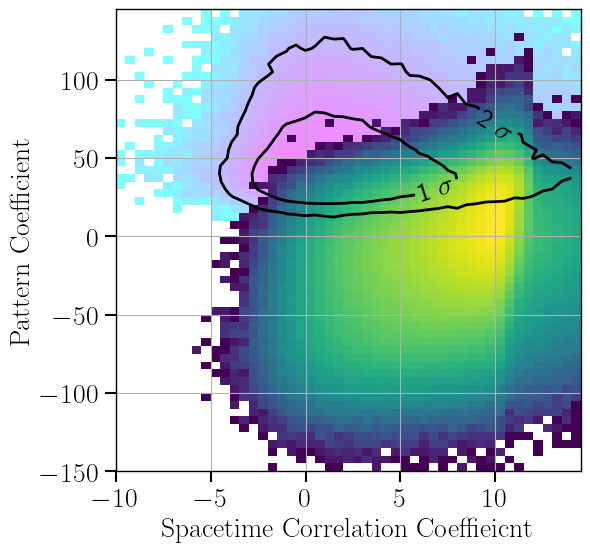

In [171]:
x_bins_area = np.arange(-10,15,0.5)
y_bins_area = np.arange(-150,150,5)


hist_new, xedges_new, yedges_new = np.histogram2d(cevns_info_roi['st_cor'], cevns_info_roi['pattern']+ k_area * cevns_info_roi['area'], bins=[x_bins_area, y_bins_area])
x_mesh_new, y_mesh_new = np.meshgrid(xedges_new[:-1], yedges_new[:-1])

# cut_array = np.arange(0,1,0.2)
cut_array = [0.683,0.954]
value_array_new = np.arange(np.min(hist_new),np.max(hist_new),1)[::-1]
cut_value_new = []
cut_index = 0
for i in value_array_new:
    # print(i,"*****")
    bigger = np.sum(hist_new[hist_new>i])
    # print(bigger)
    if (bigger > np.sum(hist_new) * cut_array[cut_index]):
        # print("!!!!!!")
        # print(i,"*****")
        # print(bigger)
        # print(cut_array[cut_index])
        cut_value_new.append(i)
        cut_index += 1
        if cut_index == len(cut_array):
            break

plt.figure(figsize=(6,6))
# 使用contour生成等高线图
contour = plt.contour(x_mesh_new, y_mesh_new,hist_new.T,cut_value_new[::-1],colors = 'k')

H = plt.hist2d(cevns_info_roi['st_cor'], cevns_info_roi['pattern'] + k_area * cevns_info_roi['area'], bins = [x_bins_area, y_bins_area],norm=LogNorm(),alpha = 0.5,label = 'CEvNS Event', cmap='cool')
H = plt.hist2d(pile_up_sp_cor_roi, pile_up_pattern_coefficient_roi +k_area * pile_up_area_roi , bins = [x_bins_area, y_bins_area], norm=LogNorm(),alpha = 1,label = 'CEvNS Event')
# 定义标签内容
# labels = [(str(int(i*100))+" \%") for i in cut_array[1:][::-1]]
labels = [r" 2 $\sigma$ ",r" 1 $\sigma$ "]
# 添加标签
plt.clabel(contour, inline=1, fontsize=20, fmt=dict(zip(contour.levels, labels)))
plt.xlabel(r'$\mathrm{Spacetime\  Correlation\ Coeffieicnt}$')
plt.ylabel(r'$\mathrm{Pattern\ Coefficient}$')
plt.grid()
# plt.tight_layout() 
# plt.savefig("/home/cchang/RELICS_DE_sim/pattern_coefficient_dis.pdf")
plt.show()

In [172]:
score_cevns_roi = cevns_info_roi['pattern'] - (k_st * cevns_info_roi['st_cor']) + k_area * cevns_info_roi['area'] - b
score_cevns = cevns_info_area['pattern'] - (k_st * cevns_info_area['st_cor']) + k_area * cevns_info_area['area'] - b
score_DE_roi = pile_up_pattern_coefficient_roi - (k_st * pile_up_sp_cor_roi) + k_area * pile_up_area_roi - b
score_DE = pile_up_pattern_coefficient_area - (k_st * pile_up_sp_cor_area) + k_area * pile_up_area_area - b

In [173]:
np.percentile(score_DE_roi, 100-0.005)

3.0397776309976088e-15

In [174]:
# 设定分数阈值的范围
thresholds = np.arange(-350, 200, 1)  # 你可以调整这个范围和步长以适应你的数据

# 初始化两个比例的列表
left_DE_ratios = []
right_cevns_ratios = []

# 计算每个阈值下的比例
for threshold in thresholds:
    left_DE_ratio = np.sum(score_DE_roi < threshold) / len(score_DE_roi)
    right_cevns_ratio = np.sum(score_cevns_roi > threshold) / len(score_cevns_roi)
    
    left_DE_ratios.append(left_DE_ratio)
    right_cevns_ratios.append(right_cevns_ratio)

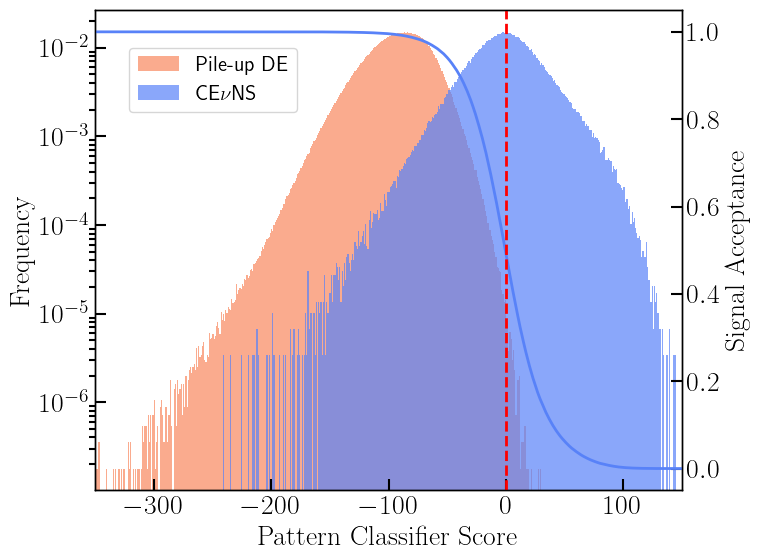

In [175]:
# 导入所需要的库
import matplotlib.pyplot as plt
import numpy as np

cevns_color = '#5882F8'
DE_color = '#F9885E'

bins = np.arange(-350, 150, 1)
score_DE_roi_dis, bins_edge = np.histogram(score_DE_roi, bins=bins) 
score_cevns_roi_dis, bins_edge = np.histogram(score_cevns_roi, bins=bins)
score_range = (bins_edge[1:] + bins_edge[:-1])/2

plt.rcParams['ytick.direction'] = 'in'
# 创建一个新的图形并设置大小
fig, ax1 = plt.subplots(figsize=(8,6))
ax1.tick_params(direction='in')
plt.tick_params(direction='in')
plt.rcParams['text.usetex'] = True

# 开始处理第一个图，使用左侧y轴

color = 'tab:blue'

ax1.hist(score_DE_roi, bins=bins, label='Pile-up DE', alpha=0.7, color=DE_color,density = True)  # 添加 alpha 参数
# ax1.plot(score_range,score_DE_roi_dis , '-', c=DE_color, label=r'$\mathrm{Pile\text{-}up\ DE}$',drawstyle='steps') 
# ax1.plot(score_range,score_cevns_roi_dis , '-', c=cevns_color, label=r"CE$\nu$NS",drawstyle='steps') 
ax1.hist(score_cevns_roi, bins=bins, label=r"CE$\nu$NS", alpha=0.7, color=cevns_color,density = True)  # 添加 alpha 参数
ax1.set_yscale('log')

ax1.set_ylabel(r'$\mathrm{Frequency}$')  # 右侧y轴标签
ax1.set_xlabel(r'$\mathrm{Pattern\ Classifier\ Score}$')  # x轴标签
# ax1.tick_params(axis='y')  # y轴标签颜色


# 第二个图，使用右侧y轴
ax2 = ax1.twinx() 
ax2.set_ylabel(r'$\mathrm{Signal\ Acceptance}$')  # 左侧y轴标签
# ax2.plot(thresholds, left_DE_ratios, label='Pile-up Cut Rate', color= DE_color)  # 绘制左侧 DE 的比例曲线
ax2.plot(thresholds, right_cevns_ratios, label=r"CE$\nu$NS Survival Rate", color=cevns_color)  # 绘制右侧 CEVNS 的比例曲线
# ax2.grid(True)
# ax2.tick_params(axis='y')  # y轴标签颜色
ax2.tick_params(direction='in')


# 获得所有子图的 legend labels 和 handles
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# 创建一个全局的legend
# fig.legend(lines + lines2, labels + labels2, loc=(0.65,0.71))
fig.legend(lines, labels, loc=(0.17,0.8))

# fig.tight_layout(pad = 5)  # 使布局紧密
# plt.title('Pattern Classifier', fontsize=16)  # 图表标题
plt.xlim(-350, 150)
plt.axvline(x=0, color='red', linestyle='dashed')
plt.tight_layout() 
plt.savefig("pattern_classifier_score_2e4.pdf")
plt.show()  # 显示绘图


In [176]:
len(pile_up_e_num_roi),len(pile_up_e_num_roi[score_DE_roi>0])

(5608664, 281)

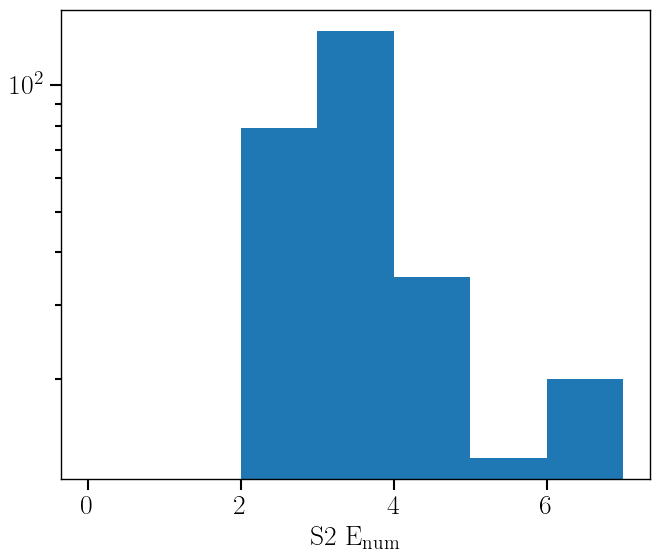

In [177]:
e_bins = np.arange(0,8,1)

fig = plt.figure(figsize=(7,6))
plt.style.use('../relics.mplstyle')  
plt.hist(pile_up_e_num_roi[score_DE_roi>0],bins = e_bins,log=True)
plt.yscale('log')
plt.xlabel(r'$\mathrm{S2\ E_{num}}$')
plt.tight_layout()
# plt.savefig("Muon_power.png")
plt.show()

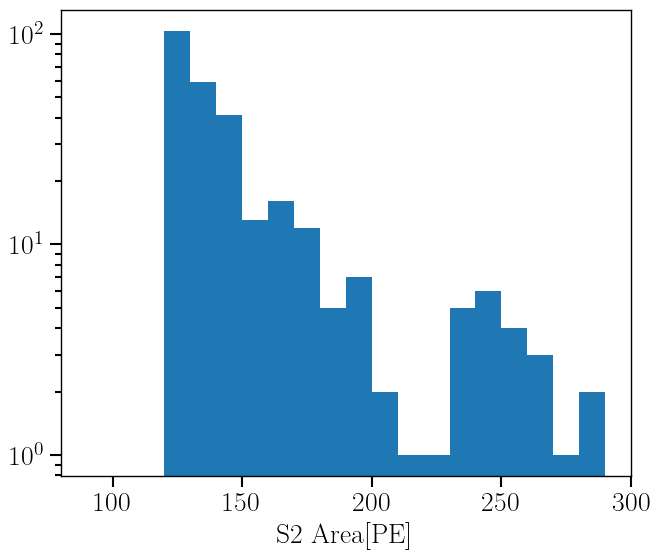

In [178]:
pe_bins = np.arange(90,300,10)

fig = plt.figure(figsize=(7,6))
plt.style.use('../relics.mplstyle')  
plt.hist(pile_up_area_roi[score_DE_roi>0],bins = pe_bins,log=True)
# plt.yscale('log')
plt.xlabel(r'$\mathrm{S2\ Area[PE]}$')
plt.tight_layout()
# plt.savefig("Muon_power.png")
plt.show()

经过筛选的DE和CEvNS的得分

In [180]:
DE_roi_hist,bins_edge = np.histogram(pile_up_area_roi[score_DE_roi>0],bins = pe_bins)
DE_hist,bins_edge = np.histogram(pile_up_area[score_DE>0],bins = pe_bins)
DE_original_hist,bins_edge = np.histogram(pile_up_area,bins = pe_bins)
cut_efficiency = DE_hist / DE_original_hist

In [181]:
CEvNS_hist,bins_edge = np.histogram(cevns_info_area[score_cevns>0]['area'],bins = pe_bins)
CEvNS_original_hist,bins_edge = np.histogram(cevns_info_area['area'],bins = pe_bins)
cut_efficiency_CEvNS = CEvNS_hist / CEvNS_original_hist

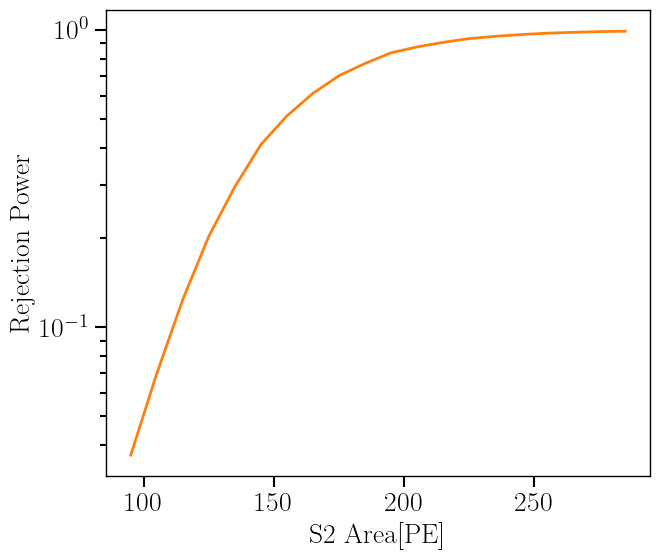

In [182]:
fig = plt.figure(figsize=(7,6))
plt.style.use('../relics.mplstyle')  
plt.plot((pe_bins[:-1] + pe_bins[1:])/2, cut_efficiency)
plt.plot((pe_bins[:-1] + pe_bins[1:])/2, cut_efficiency_CEvNS)
plt.yscale('log')
plt.xlabel(r'$\mathrm{S2\ Area[PE]}$')
plt.ylabel(r'$\mathrm{Rejection\ Power}$')
plt.tight_layout()
# plt.savefig("Muon_power.png")
plt.show()

In [183]:
np.sum(DE_hist[3:]) / np.sum(DE_original_hist[3:])

0.0

逐文件处理筛选+波形生成
======

In [200]:
# 根据电子时间以及单电子弥散生成对应peak波形
def waveform_gen(pe_info,sigma_se):
    pe_num = len(pe_info)
    se_signal_delay = np.random.normal(0,sigma_se,pe_num)
    pe_time = pe_info['e_time'] + se_signal_delay
    pe_time = pe_time - np.mean(pe_time)
    # print(pe_time)
    sample_index = pe_time / (4e-9)
    sample_index = sample_index.astype(int)
    # print(sample_index)
    waveform = np.zeros(3500)
    np.add.at(waveform,sample_index + 1750,pe_info['area']/6e6)
    # np.add.at(waveform,sample_index + 1750,1)
    # print(pe_info['area']/6e6)
    # fig = plt.figure(figsize=(7, 4))
    # plt.plot(waveform[1000:-1000])
    # plt.show()
    return waveform

In [217]:
# 根据模拟的结果，对于pattern过阈的事件，生成波形并记录面积，电子数等信息
waveform_list = []
pile_up_pattern_coefficient_list = []
pile_up_area_list = []
pile_up_e_num_list = []
pile_up_sp_cor_list = []
file_index_list = []


sigma_se = 190e-9
for i in tqdm(range(len(file_list))):
# for i in tqdm(range(100)):
    file = np.load(file_list[i])
    pile_up_pattern_coefficient_file = file['pile_up_pattern_coefficient']
    pile_up_area_file =  file["pile_up_area"]
    # area_pattern =  data_save["area_pattern"]
    pile_up_pe_info_file = file["pile_up_pe_info"]
    pile_up_e_num_file =  file["pile_up_e_num"]
    pile_up_sp_cor_file = file['pile_up_sp_cor']
    event_id_file = np.arange(len(pile_up_area_file))
    
    score_DE_file = pile_up_pattern_coefficient_file - (k_st * pile_up_sp_cor_file) + k_area * pile_up_area_file - b
    
    event_id_remain_file = event_id_file[score_DE_file > 0]
    pile_up_pattern_coefficient_list.append(pile_up_pattern_coefficient_file[score_DE_file > 0])
    pile_up_area_list.append(pile_up_area_file[score_DE_file > 0])
    pile_up_e_num_list.append(pile_up_e_num_file[score_DE_file > 0])
    pile_up_sp_cor_list.append(pile_up_sp_cor_file[score_DE_file > 0])
    
    for event_id in event_id_remain_file:
        pe_info = pile_up_pe_info_file[pile_up_pe_info_file['event_id'] == event_id]
        # print(pe_info)
        # print("pile_up_e_num: ", pile_up_e_num_file[event_id])
        # print("pile_up_area: ", pile_up_area_file[event_id])
        waveform = waveform_gen(pe_info,sigma_se)
        waveform_list.append(waveform)
        file_index_list.append(i)
        # fig = plt.figure(figsize=(6,3))
        # plt.plot(waveform[875:-875])
        # plt.show()
    np.savez(f'result_0822/waveform_{i}.npz',
             pile_up_pattern_coefficient=pile_up_pattern_coefficient_file[score_DE_file > 0],
             pile_up_area=pile_up_area_file[score_DE_file > 0],
             pile_up_e_num_list=pile_up_e_num_file[score_DE_file > 0],
             pile_up_sp_cor = pile_up_sp_cor_file[score_DE_file > 0],
             waveform = waveform
            ) 
    
    del file

100%|██████████████████████████████████████████████████████████████████████████████████| 18459/18459 [2:58:31<00:00,  1.72it/s]


In [31]:
# 从原有的模拟数据中摘取pattern相关内容
pile_up_pattern_coefficient_list = []
pile_up_area_list = []
pile_up_e_num_list = []
pile_up_sp_cor_list = []

for i in tqdm(range(len(file_list))):
    file = np.load(file_list[i])
    pile_up_pattern_coefficient = file['pile_up_pattern_coefficient']
    pile_up_area =  file["pile_up_area"]
    # area_pattern =  data_save["area_pattern"]
    # pile_up_pe_info = data_save["pile_up_pe_info"]
    pile_up_e_num =  file["pile_up_e_num"]
    pile_up_sp_cor = file['pile_up_sp_cor']
    
    pile_up_pattern_coefficient_list.append(pile_up_pattern_coefficient)
    pile_up_area_list.append(pile_up_area)
    pile_up_e_num_list.append(pile_up_e_num)
    pile_up_sp_cor_list.append(pile_up_sp_cor)
    
    np.savez("sim_result/pattern_coefficient_" + str(i) + ".npz",
             pile_up_pattern_coefficient=pile_up_pattern_coefficient,
             pile_up_area=pile_up_area,
             pile_up_e_num=pile_up_e_num,
             pile_up_sp_cor = pile_up_sp_cor
            )
    
    del file
    
pile_up_pattern_coefficient = np.concatenate(pile_up_pattern_coefficient_list)
pile_up_area = np.concatenate(pile_up_area_list)
pile_up_e_num = np.concatenate(pile_up_e_num_list)
pile_up_sp_cor = np.concatenate(pile_up_sp_cor_list)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 18459/18459 [09:21<00:00, 32.89it/s]


In [218]:
# 保存所有pattern过阈事件的波形
waveform_array = np.array(waveform_list)
np.save('waveform_DE_2e4_0822_long', waveform_array)

读取过阈数据，包括面积，电子数，pattern以及sp_cor

In [219]:
# 使用os.walk()获取生成器对象  
generator = os.walk('result_0822')  
result_file_list = []
  
# 遍历生成器对象  
for root, dirs, files in generator:  
    # 遍历目录下的所有文件  
    for file in files:  
        # 打印文件的完整路径  
        result_file_list.append(os.path.join(root, file))

waveform_list = []
pile_up_pattern_coefficient_list = []
pile_up_area_list = []
pile_up_e_num_list = []
pile_up_sp_cor_list = []
file_index_list = []

for i in tqdm(range(len(result_file_list))):
    file = np.load(result_file_list[i])
    pile_up_pattern_coefficient_list.append(file['pile_up_pattern_coefficient'])
    pile_up_area_list.append(file['pile_up_area'])
    pile_up_e_num_list.append(file['pile_up_e_num_list'])
    pile_up_sp_cor_list.append(file['pile_up_sp_cor'])
    

100%|████████████████████████████████████████████████████████████████████████████████████| 18459/18459 [04:18<00:00, 71.28it/s]


读取DE_pile_up波形数据

In [220]:
# 转换数据通道数为1并调整大小
waveform_array = np.load('waveform_DE_2e4_0822_long.npy')
test_de_data = waveform_array.reshape(-1, 1, 3500)
test_de_labels = np.zeros(len(test_de_data))
test_de_pe = np.sum(np.sum(test_de_data,axis = 1),axis = 1)

# test_cevns_data = np.concatenate(wf_cevns)
# # 转换数据通道数为1并调整大小
# test_cevns_data = test_cevns_data.reshape(-1, 1, 3500)
# test_cevns_labels = np.ones(len(test_cevns_data))
# test_cevns_pe = np.sum(np.sum(test_cevns_data,axis = 1),axis = 1)

test_data = test_de_data.reshape(-1, 1, 3500)
test_labels = np.zeros(len(test_data))
test_pe = np.sum(np.sum(test_data,axis = 1),axis = 1)

# test_data = np.concatenate([test_de_data,test_cevns_data])
# test_labels = np.concatenate([test_de_labels,test_cevns_labels])
# test_pe = np.concatenate([test_de_pe,test_cevns_pe])

DE_pile_up波形鉴别

In [221]:
import torch
import torch.nn as nn
import pickle
from PIL import Image
import h5py

#神经网络的结构，得跑一下才能把后面有些定义的变量弄进去，不耗时间
class WaveformClassifier(nn.Module):
    def __init__(self):
        super(WaveformClassifier, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.global_pool = nn.AdaptiveAvgPool1d(1)  # 使用全局平均池化层
        self.fc = nn.Sequential(
            nn.Linear(128, 64),  # 修改全连接层的输入维度
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(32, 2)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.global_pool(x).squeeze(2)
        x = self.fc(x)
        return x
    

In [222]:
#把测试集的名字换成我们需要的，test_filename = 'test3.pkl'，这个。然后用已经做好的模型model.load_state_dict(torch.load('waveform_classifier.pth'))得到一个分数
#这个分数存在h5_filename = 'scores3.h5'这里面

# # 加载测试集数据和标签
# test_filename = 'test3.pkl'
# 长度为3500的波形？
# train_loss_values = []  # 保存训练损失值的列表
# test_loss_values = []   # 保存测试损失值的列表

# with open(test_filename, 'rb') as f:
#     test_data, test_labels, test_pe = pickle.load(f)



# # 转换数据通道数为1并调整大小
# test_data = test_data.reshape(-1, 1, 3500)

# 将测试集数据和标签转换为PyTorch张量
test_data = torch.from_numpy(test_data).float()
test_labels = torch.from_numpy(test_labels).long()

# 创建测试集数据集和数据加载器
test_dataset = torch.utils.data.TensorDataset(test_data, test_labels)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

# 加载模型
model = WaveformClassifier()
model.load_state_dict(torch.load('../waveform_classifier.pth'))


# 测试模式
model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0
test_confusion_matrix = torch.zeros(2, 2)
criterion = nn.CrossEntropyLoss()

num_epochs = 2
with torch.no_grad():
    for batch_data, batch_labels in test_dataloader:
        outputs = model(batch_data)
        loss = criterion(outputs, batch_labels)
        test_loss += loss.item() * batch_data.size(0)

        # 计算测试集准确率和混淆矩阵
        _, predicted = torch.max(outputs, 1)
        test_total += batch_labels.size(0)
        test_correct += (predicted == batch_labels).sum().item()

        for i in range(len(predicted)):
            test_confusion_matrix[batch_labels[i]][predicted[i]] += 1

# 计算平均测试集损失函数和准确率
test_loss /= len(test_dataset)
test_accuracy = test_correct / test_total

# 计算标签0判断为标签1和标签1判断为标签0的概率
test_false_positive = test_confusion_matrix[0][1] / test_confusion_matrix[0].sum()
test_false_negative = test_confusion_matrix[1][0] / test_confusion_matrix[1].sum()

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
print(f"Test False Positive Rate: {test_false_positive:.4f}, Test False Negative Rate: {test_false_negative:.4f}")


# 在测试集上进行评估
model.eval()
test_confusion_matrix = torch.zeros(2, 2)

# 在测试集上计算预测分数
with torch.no_grad():
    model.eval()
    outputs = model(test_data)
    scores = torch.softmax(outputs, dim=1)

# 绘制预测分数的分布
scores_label_0 = scores[test_labels == 0]
scores_label_1 = scores[test_labels == 1]


Test Loss: 0.9746, Test Accuracy: 0.7181
Test False Positive Rate: 0.2819, Test False Negative Rate: nan


/home/cchang/.conda/envs/geant4/lib/python3.8/site-packages/numpy/lib/histograms.py:906: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


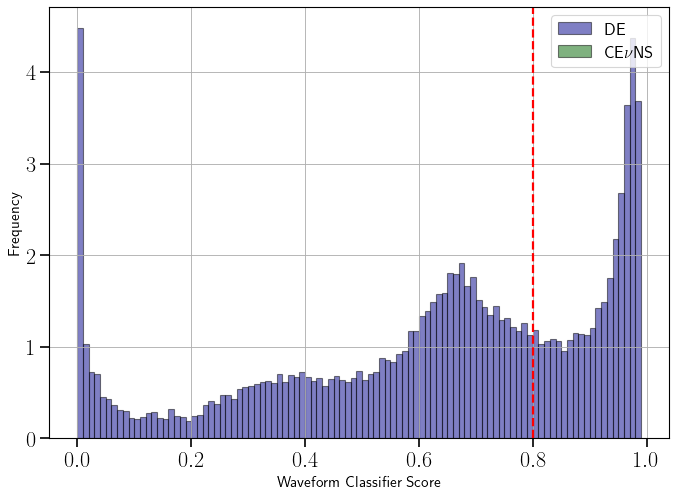

In [223]:
import matplotlib.pyplot as plt
# 创建一个新的图形并设置大小
fig= plt.figure(figsize=(10, 7),dpi = 80)
plt.hist(scores_label_0[:, 0].numpy(), bins=np.arange(0,1,0.01), edgecolor='black', alpha=0.5, label='DE', density=True, color='darkblue')
plt.hist(scores_label_1[:, 0].numpy(), bins=np.arange(0,1,0.01), edgecolor='black', alpha=0.5, label=r"CE$\nu$NS", density=True, color='darkgreen')

plt.xlabel('Waveform Classifier Score', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
#plt.title('Distribution of Prediction Scores')
plt.legend()
# plt.savefig('defen.svg', transparent=True, dpi=400, bbox_inches='tight')
plt.axvline(x=0.8, color='red', linestyle='dashed')
plt.grid()
plt.show()


# h5_filename = 'scores3.h5'
# h5_file = h5py.File(h5_filename, 'w')

# # 将得分存储为名为'scores'的数据集
# h5_file.create_dataset('scores', data=scores.numpy())

# # 关闭HDF5文件
# h5_file.close()


In [224]:
DE_waveform_score = scores_label_0[:, 0].numpy()

In [225]:
pile_up_pattern_coefficient_array = np.concatenate(pile_up_pattern_coefficient_list)
pile_up_area_array = np.concatenate(pile_up_area_list)
pile_up_e_num_array = np.concatenate(pile_up_e_num_list)
pile_up_sp_cor_array = np.concatenate(pile_up_sp_cor_list)
file_index_array = np.array(file_index_list)

In [270]:
len(pile_up_e_num_array),len(pile_up_pattern_coefficient_array),len(DE_waveform_score)

(25009, 25009, 25009)

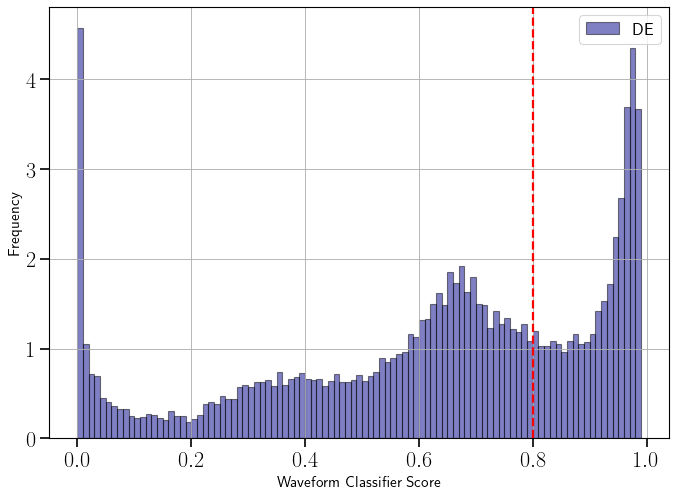

In [228]:
fig= plt.figure(figsize=(10, 7),dpi = 80)
plt.hist(DE_waveform_score[pile_up_e_num_array==2], bins=np.arange(0,1,0.01), edgecolor='black', alpha=0.5, label='DE', density=True, color='darkblue')

plt.xlabel('Waveform Classifier Score', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
#plt.title('Distribution of Prediction Scores')
plt.legend()
# plt.savefig('defen.svg', transparent=True, dpi=400, bbox_inches='tight')
plt.axvline(x=0.8, color='red', linestyle='dashed')
plt.grid()
plt.show()

In [274]:
fig= plt.figure(figsize=(10, 7),dpi = 80)
plt.hist(pile_up_area_array, bins=np.arange(90,300,10), edgecolor='black', alpha=0.5, label='DE', color='darkblue')
plt.hist(pile_up_area_array[pile_up_e_num_array == 6], bins=np.arange(90,300,10), edgecolor='black', alpha=0.5, label='DE6')
plt.hist(pile_up_area_array[pile_up_e_num_array == 5], bins=np.arange(90,300,10), edgecolor='black', alpha=0.5, label='DE5')
plt.hist(pile_up_area_array[DE_waveform_score>0.8], bins=np.arange(90,240,10), edgecolor='black', alpha=1, label='DE', color='orange')
plt.xlabel('Waveform Classifier Score', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
# plt.title('Distribution of Prediction Scores')
# plt.legend()
# plt.savefig('defen.svg', transparent=True, dpi=400, bbox_inches='tight')
# plt.grid()
plt.show()

RuntimeError: latex was not able to process the following string:
b'$\\\\mathdefault{275}$'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp3ycq45ty d0a6963b7be7771a68bb153e308d5a23.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./d0a6963b7be7771a68bb153e308d5a23.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)

! LaTeX Error: File `type1ec.sty' not found.

Type X to quit or <RETURN> to proceed,
or enter new name. (Default extension: sty)

Enter file name: 
! Emergency stop.
<read *> 
         
l.8 \usepackage
               [utf8]{i

<Figure size 800x560 with 1 Axes>

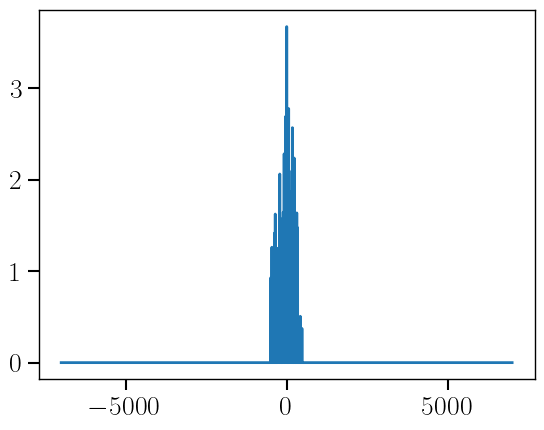

In [275]:
sigma_array = ((np.arange(3500) - np.mean(np.arange(3500))) * 4)**2
time_array = (np.arange(3500) - np.mean(np.arange(3500))) * 4

plt.plot(time_array, waveform_array[0])
plt.show()

计算波形宽度，运用s2_width cut

In [277]:
def width_calculate(waveform,sigma_array):
    waveform_std = np.sum(waveform * sigma_array / np.sum(waveform))**0.5
    return waveform_std
width_list = []
for i in tqdm(range(len(waveform_array))):
    waveform = waveform_array[i]
    width_list.append(width_calculate(waveform,sigma_array))
width_array = np.array(width_list)

100%|█████████████████████████████████████████████████████████████████████████████████| 25009/25009 [00:00<00:00, 39069.48it/s]


In [278]:
width_cut = width_array>220

In [284]:
len(pile_up_area_array[width_cut*(DE_waveform_score>0.8)]) / len(DE_waveform_score),len(DE_waveform_score[DE_waveform_score < 0.8]) / len(DE_waveform_score)

(0.21316326122595866, 0.6606821544244073)

In [283]:
fig= plt.figure(figsize=(10, 7),dpi = 80)
plt.hist(pile_up_area_array, bins=np.arange(90,300,10), edgecolor='black', alpha=0.5, label='DE after pattern', color='darkblue')
plt.hist(pile_up_area_array[DE_waveform_score>0.8], bins=np.arange(90,300,10), edgecolor='black', alpha=1, label='DE after pattern+waveform', color='orange')
plt.hist(pile_up_area_array[width_cut*(DE_waveform_score>0.8)], bins=np.arange(90,300,10), edgecolor='black', alpha=1, label='DE after pattern+width+waveform')
# plt.hist(pile_up_area_array[(DE_waveform_score>0.8) * width_cut], bins=np.arange(90,250,10), edgecolor='black', alpha=1, label='DE after patter, width, waveform', color='orange')

plt.xlabel('S2 Area[pe]', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
#plt.title('Distribution of Prediction Scores')
plt.legend()
plt.savefig('DE_freq.pdf', transparent=True, dpi=400, bbox_inches='tight')
plt.grid()
plt.show()

RuntimeError: latex was not able to process the following string:
b'$\\\\mathdefault{275}$'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpio__qexi d0a6963b7be7771a68bb153e308d5a23.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./d0a6963b7be7771a68bb153e308d5a23.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)

! LaTeX Error: File `type1ec.sty' not found.

Type X to quit or <RETURN> to proceed,
or enter new name. (Default extension: sty)

Enter file name: 
! Emergency stop.
<read *> 
         
l.8 \usepackage
               [utf8]{i

In [285]:
DE_spectrum,bins_edge = np.histogram(pile_up_area_array[(DE_waveform_score>0.8) * width_cut], bins=np.arange(90,301,10))

In [286]:
DE_spectrum.shape,np.arange(90,300,10).shape,DE_spectrum

((21,),
 (21,),
 array([1856, 1354,  857,  435,  292,  160,  102,   52,   53,   32,   13,
          13,   19,   13,   19,   11,   19,   15,    6,    7,    3]))

In [294]:
len(file_list)

18459

In [298]:
20000 * 5 * (8.5 / 100) / 24 / 365

0.9703196347031964

In [299]:
np.sum(DE_spectrum[3:10]) / ((8.5 / 100) * (len(file_list) * 5)) * 24 * 365, np.sum(DE_spectrum[3:10])

(1257.3187636829473, 1126)

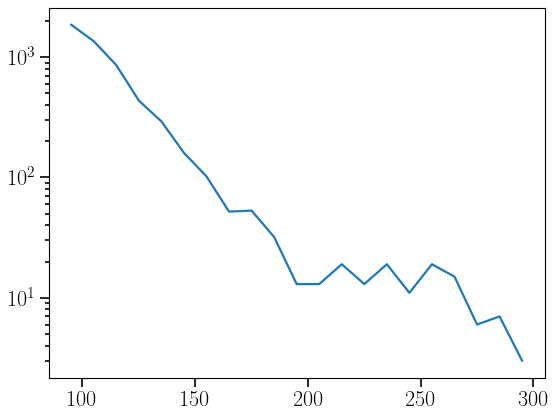

In [305]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=80)
ax.plot((bins_edge[1:] + bins_edge[:-1])/2, DE_spectrum)
ax.set_yscale("log")
plt.show()

In [306]:
DE_rate = DE_spectrum / ((8.5 / 100) * (len(file_list) * 5)) * 24 / 31 / 10 # 10是每个bin10个pe取平均
DE_rate_error = (DE_spectrum)**0.5 / ((8.5 / 100) * (len(file_list) * 5)) * 24 / 31 / 10

np.savez('DE_rate.npz', DE_rate=DE_rate, DE_rate_error=DE_rate_error) 

# pile_up rate比较

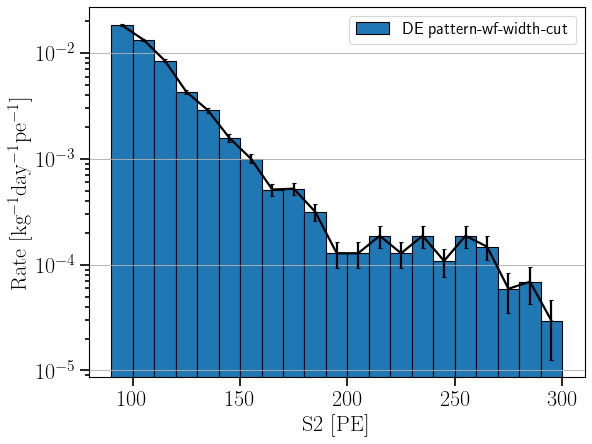

In [307]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6), dpi=80)

# 创建一个柱状图并添加误差条
ax.bar((bins_edge[1:] + bins_edge[:-1])/2, DE_rate, edgecolor = "black", label = "DE pattern-wf-width-cut",width=10,)
ax.errorbar((bins_edge[1:] + bins_edge[:-1])/2, DE_rate, yerr=DE_rate_error, color = "black")

ax.set_xlabel(r"$\mathrm{S2\ [PE]}$")
ax.set_ylabel(r"$\mathrm{Rate\ [kg^{-1} day^{-1} pe^{-1}]}$")
ax.set_yscale("log")

# 设置y轴的刻度为每个10的n次方
# ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0))
# ax.tick_params(direction='in')
# 增加背景刻度线
ax.grid(which='major', axis='y')

plt.legend()
plt.savefig("DE_rate.pdf")

plt.show()

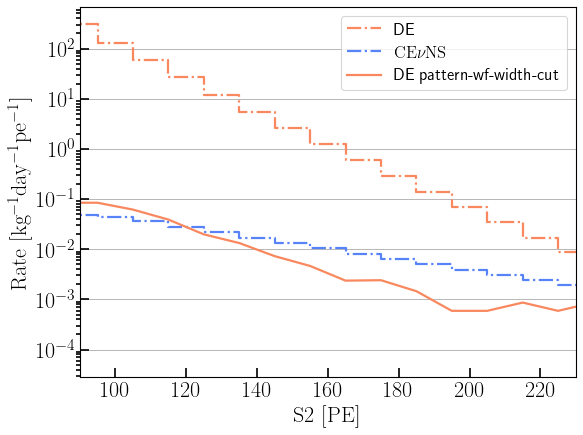

In [255]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=80)
# 创建一个柱状图并添加误差条
# ax.bar((bins_edge[1:] + bins_edge[:-1])/2, DE_rate_original, edgecolor = "black", label=r"DE",width=10,)
# ax.bar((bins_edge[1:] + bins_edge[:-1])/2, cevns_rate_original, edgecolor = "black", label=r"CE$\nu$NS",width=10,)
ax.plot(pe,rate_DE ,  '-.', c='#F9885E', label=r"DE",drawstyle='steps') 
ax.plot(pe,rate_CEvNS , '-.', c='#5882F8', label=r'$\mathrm{CE\nu NS}$', drawstyle='steps') 
rate_DE_cut = np.insert(DE_rate, 0, DE_rate[0])
ax.plot(pe, rate_DE_cut, '-', c='#F9885E', label = "DE pattern-wf-width-cut")
# ax.errorbar((bins_edge[1:] + bins_edge[:-1])/2, DE_rate, yerr=DE_rate_error, color = "black")

ax.set_xlabel(r"$\mathrm{S2\ [PE]}$")
ax.set_ylabel(r"$\mathrm{Rate\ [kg^{-1} day^{-1} pe^{-1}]}$")
ax.set_yscale("log")
ax.set_xlim(90, 230)

# 设置y轴的刻度为每个10的n次方
# ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0))
ax.tick_params(direction='in')
# 增加背景刻度线
ax.grid(which='major', axis='y')

plt.legend()
plt.savefig("DE_cut_rate.pdf")
plt.show()

In [256]:
acceptance_e = [0.08807451, 0.15816423, 0.32882983, 0.54858427, 0.64094367,0.70614694, 0.73163086]

In [257]:
np.savez("DE_spctrum.npz", DE_pe_spec = DE_rate, DE_pe_spec_err = DE_rate_error,DE_bins_edge = bins_edge)

In [258]:
data = np.load("DE_spctrum.npz")
num = data['DE_pe_spec'] 
error = data['DE_pe_spec_err']
bins = data['DE_bins_edge']

In [261]:
e_spectrum = np.array([1021.5997675574218,474.2178801236556,222.03279893822705,104.35334139728404,50.258124794689884]) * 0.73

In [262]:
e_spectrum * 32

array([23864.57057014, 11077.72967969,  5186.6861832 ,  2437.69405504,
        1174.0297952 ])

In [263]:
rate_DE_cut = np.array([0.00488197, 0.00488197, 0.00638482, 0.00534649, 0.00388008,
       0.0025685 , 0.00195825, 0.00118406, 0.00090171, 0.00046452,
       0.00031879, 0.00017306, 0.00020949, 0.00014573, 0.00018216,
       0.00013662, 0.        ])

In [264]:
pe

array([ 85.,  95., 105., 115., 125., 135., 145., 155., 165., 175., 185.,
       195., 205., 215., 225., 235., 245., 255., 265., 275., 285., 295.])

In [268]:
DE_spectrum_original,bins_edge = np.histogram(pile_up_area, bins=np.arange(90,301,10))
cevns_spectrum_original,bins_edge = np.histogram(cevns_info_area['area'], bins=np.arange(90,301,10))

DE_rate_original = DE_spectrum_original / 850 * 24 / 32 / 10 #100个文件，850h
cevns_rate_original = cevns_spectrum_original / 20 / 365 / 10 / 32

# 在最左侧插入数据点
pe = (bins_edge[1:] + bins_edge[:-1])/2
rate_DE = DE_rate_original
rate_CEvNS = cevns_rate_original
pe = np.insert(pe, 0, pe[0] - 10)
rate_DE = np.insert(rate_DE, 0, rate_DE[0])
rate_CEvNS = np.insert(rate_CEvNS, 0, rate_CEvNS[0])

import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6), dpi=80)
# 创建一个柱状图并添加误差条
# ax.bar((bins_edge[1:] + bins_edge[:-1])/2, DE_rate_original, edgecolor = "black", label=r"DE",width=10,)
# ax.bar((bins_edge[1:] + bins_edge[:-1])/2, cevns_rate_original, edgecolor = "black", label=r"CE$\nu$NS",width=10,)
ax.plot(pe,rate_DE ,  '-.', c='#F9885E', label=r"DE",drawstyle='steps') 
ax.plot(pe,rate_CEvNS , '-.', c='#5882F8', label=r'$\mathrm{CE\nu NS}$', drawstyle='steps') 
ax.plot(pe, rate_DE_cut, '-', c='#F9885E', label = "DE pattern-wf-width-cut", drawstyle='steps')
ax.plot(pe, rate_CEvNS * y_new, '-', c='#5882F8', label = r"$\mathrm{CE\nu NS}$ " + "pattern-wf-width-cut", drawstyle='steps')
ax.set_xlabel(r"$\mathrm{S2\ [PE]}$")
ax.set_ylabel(r"$\mathrm{Rate\ [kg^{-1} day^{-1} pe^{-1}]}$")
ax.set_yscale("log")
ax.set_xlim(100, 305)

# 设置y轴的刻度为每个10的n次方
# ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0))
ax.tick_params(direction='in')
# 增加背景刻度线
ax.grid(which='major', axis='y')

plt.legend()
plt.savefig("DE_rate_cut.pdf")
plt.show()

ValueError: x and y must have same first dimension, but have shapes (22,) and (17,)